<a href="https://colab.research.google.com/github/MohammadYusif/time-series-forecasting-ai-systems/blob/main/day3/05_lab_probabilistic_forecasts.ipynb" target="_blank" rel="noopener"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a>


## Lab 5 — Probabilistic Forecasts

Every lab so far has produced a single number per future day: the point
forecast. This lab produces a **range** instead — a prediction interval
that says "the actual value will very likely land between X and Y," which
is what objective 6 (produce probabilistic forecasts with prediction
intervals) actually asks for.

A point forecast that's off by 40 units and a point forecast that's off by
40 units but *told you it might be off by 40 units* are very different
tools for a planner deciding how much safety stock to carry. This lab
builds an 80% interval three different ways and checks whether each one
delivers on its promise:

- **Prophet** — a fitted additive model with intervals built in.
- **Quantile LightGBM** — three separate gradient-boosted models, each
  trained to predict a different quantile of the outcome distribution.
- **sktime** — a classical statistical forecaster's own interval method,
  behind the same `predict_interval` API sktime gives every forecaster it
  wraps.

"Delivers on its promise" has two parts, and a model can cheat on either
one alone:
- **Coverage** — of the actual holdout points, what fraction really fell
  inside the interval? A well-calibrated 80% interval should cover close
  to 80%.
- **Width** — how wide is the interval? An interval that covers 100% by
  being absurdly wide is not useful; report width next to coverage,
  always, never coverage alone (see `common/metrics.py`'s `coverage` and
  `interval_width` docstrings).

Same series as Labs 2-4: `data/retail_demand.csv`, Riyadh/Grocery, last 60
days held out.

In [1]:
import subprocess, sys

def _pip_install(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)

_pip_install("pandas", "numpy", "matplotlib", "lightgbm", "prophet", "sktime")

import pathlib
import urllib.request

REPO = "MohammadYusif/time-series-forecasting-ai-systems"
BRANCH = "main"

def fetch(rel_path: str) -> str:
    """Locate rel_path from a repo checkout (tries rel_path and ../rel_path
    — labs live one directory below the repo root) or download it from
    GitHub if neither exists (a fresh Colab runtime)."""
    for candidate in (rel_path, f"../{rel_path}"):
        if pathlib.Path(candidate).exists():
            return candidate
    dest = pathlib.Path(pathlib.Path(rel_path).name)
    if not dest.exists():
        url = f"https://raw.githubusercontent.com/{REPO}/{BRANCH}/{rel_path}"
        urllib.request.urlretrieve(url, dest)
    return str(dest)

sys.path.insert(0, str(pathlib.Path(fetch("common/metrics.py")).parent))
from metrics import mae, rmse, mape, smape, wape, mase, pinball_loss, coverage, interval_width

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

RNG_SEED = 20260912
np.random.seed(RNG_SEED)


> **A note on the first run.** Prophet's first fit in a fresh environment
> compiles and caches a `cmdstan` model in the background — that can take
> anywhere from a few seconds to a couple of minutes the first time
> `Prophet().fit(...)` runs in this notebook. That pause is normal, not a
> hang; every fit after the first one in this environment is fast.

### Load the data and hold out the last 60 days

In [2]:
df = pd.read_csv(fetch("data/retail_demand.csv"), parse_dates=["date"])
series = (
    df[(df["region"] == "Riyadh") & (df["category"] == "Grocery")]
    .sort_values("date")
    .reset_index(drop=True)[["date", "units_sold"]]
)

HORIZON = 60
train = series.iloc[:-HORIZON].reset_index(drop=True)
test = series.iloc[-HORIZON:].reset_index(drop=True)
y_true = test["units_sold"].values

print(f"train: {len(train)} days ({train['date'].min().date()} to {train['date'].max().date()})")
print(f"test:  {len(test)} days ({test['date'].min().date()} to {test['date'].max().date()})")


train: 1036 days (2023-01-01 to 2025-11-01)
test:  60 days (2025-11-02 to 2025-12-31)


### 1. Prophet

Prophet fits an additive model (trend + seasonalities + holidays) and
gives you a prediction interval for free on every forecast — no extra
step. Its one hard requirement: the input dataframe must have exactly two
columns named `ds` (the date) and `y` (the value).

In [3]:
from prophet import Prophet

prophet_train = train.rename(columns={"date": "ds", "units_sold": "y"})[["ds", "y"]]

prophet_model = Prophet(interval_width=0.8)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=HORIZON, freq="D")
prophet_forecast = prophet_model.predict(future).tail(HORIZON).reset_index(drop=True)

prophet_yhat = prophet_forecast["yhat"].values
prophet_lower = prophet_forecast["yhat_lower"].values
prophet_upper = prophet_forecast["yhat_upper"].values

prophet_mae = mae(y_true, prophet_yhat)
prophet_wape = wape(y_true, prophet_yhat)
prophet_coverage = coverage(y_true, prophet_lower, prophet_upper)
prophet_width = interval_width(prophet_lower, prophet_upper)
prophet_pinball = pinball_loss(y_true, prophet_yhat, 0.5)

print(f"Prophet   MAE={prophet_mae:.1f}  WAPE={prophet_wape:.1f}%  "
      f"80% coverage={prophet_coverage:.1%}  width={prophet_width:.1f}  "
      f"pinball@0.5={prophet_pinball:.1f}")


Importing plotly failed. Interactive plots will not work.


16:31:18 - cmdstanpy - INFO - Chain [1] start processing


16:31:19 - cmdstanpy - INFO - Chain [1] done processing


Prophet   MAE=29.8  WAPE=5.0%  80% coverage=100.0%  width=341.1  pinball@0.5=14.9


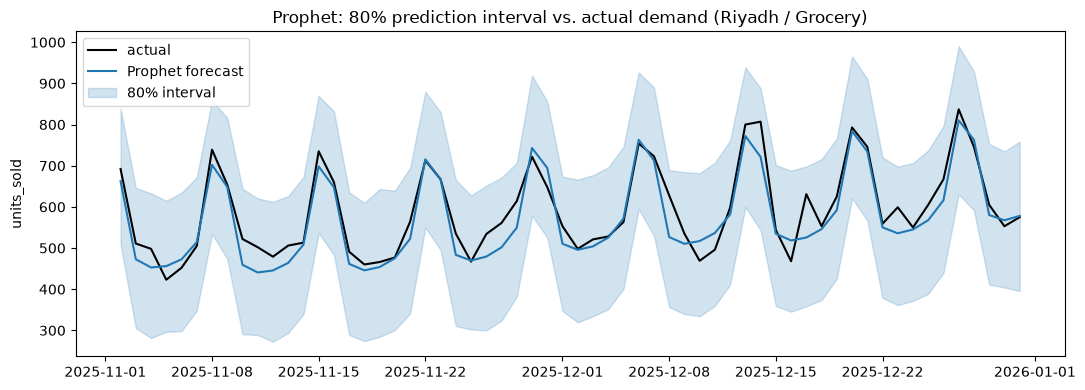

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(test["date"], y_true, label="actual", color="black", linewidth=1.5)
ax.plot(test["date"], prophet_yhat, label="Prophet forecast", color="#1f77b4")
ax.fill_between(test["date"], prophet_lower, prophet_upper, color="#1f77b4", alpha=0.2, label="80% interval")
ax.set_title("Prophet: 80% prediction interval vs. actual demand (Riyadh / Grocery)")
ax.set_ylabel("units_sold")
ax.legend()
fig.tight_layout()
plt.show()


### 2. Quantile LightGBM

LightGBM has no built-in notion of an interval, but it can be trained to
minimize **pinball loss at a chosen quantile** instead of the usual
squared error — pass `objective="quantile", alpha=q`. Fit the same model
three times, once per quantile (0.1, 0.5, 0.9), and the 0.1/0.9 pair *is*
an 80% interval by construction (10% of mass below, 10% above).

Same lag/rolling/calendar features as Lab 3's LightGBM forecaster, and the
same recursive multi-step loop: each model predicts one day at a time, and
its own prediction — not the true future value, which the model is not
allowed to see — becomes the lag input for the next day. The loop body is
written once and reused for all three quantiles so the three forecasts
can't quietly drift out of sync with each other.

In [5]:
def make_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Calendar + lag + rolling features. Every lag/rolling column is built
    from `units_sold.shift(1)` or later — never from the current row — so
    it can be computed identically whether that row's true value is known
    (training) or not yet known (a recursive forecast step)."""
    frame = frame.copy()
    frame["dow"] = frame["date"].dt.dayofweek
    frame["month"] = frame["date"].dt.month
    frame["is_weekend"] = frame["dow"].isin([4, 5]).astype(int)  # Fri/Sat, KSA weekend
    for lag in (1, 7, 14, 28):
        frame[f"lag_{lag}"] = frame["units_sold"].shift(lag)
    frame["roll_mean_7"] = frame["units_sold"].shift(1).rolling(7).mean()
    frame["roll_mean_28"] = frame["units_sold"].shift(1).rolling(28).mean()
    frame["roll_std_7"] = frame["units_sold"].shift(1).rolling(7).std()
    return frame


FEATURE_COLS = [
    "dow", "month", "is_weekend",
    "lag_1", "lag_7", "lag_14", "lag_28",
    "roll_mean_7", "roll_mean_28", "roll_std_7",
]

train_features = make_features(train).dropna().reset_index(drop=True)
X_train = train_features[FEATURE_COLS]
y_train_lgb = train_features["units_sold"]


def recursive_forecast(model, history_df: pd.DataFrame, horizon: int) -> np.ndarray:
    """Forecast `horizon` steps ahead one day at a time. Each step's
    features are recomputed on `history` AFTER appending the previous
    step's prediction — so lag_1..lag_28 for a future date come from real
    history where it exists and from this model's own earlier predictions
    where it doesn't, never from the true (held-out) future."""
    history = history_df.copy().reset_index(drop=True)
    preds = []
    last_date = history["date"].iloc[-1]
    for step in range(horizon):
        next_date = last_date + pd.Timedelta(days=step + 1)
        extended = pd.concat(
            [history, pd.DataFrame({"date": [next_date], "units_sold": [np.nan]})],
            ignore_index=True,
        )
        x_next = make_features(extended).iloc[[-1]][FEATURE_COLS]
        y_hat = float(model.predict(x_next)[0])
        preds.append(y_hat)
        history = pd.concat(
            [history, pd.DataFrame({"date": [next_date], "units_sold": [y_hat]})],
            ignore_index=True,
        )
    return np.array(preds)


In [6]:
from lightgbm import LGBMRegressor

QUANTILES = (0.1, 0.5, 0.9)
lgb_forecasts = {}

for q in QUANTILES:
    model = LGBMRegressor(
        objective="quantile",
        alpha=q,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=RNG_SEED,
        verbosity=-1,
    )
    model.fit(X_train, y_train_lgb)
    lgb_forecasts[q] = recursive_forecast(model, train, HORIZON)

lgb_lower, lgb_median, lgb_upper = lgb_forecasts[0.1], lgb_forecasts[0.5], lgb_forecasts[0.9]

lgb_mae = mae(y_true, lgb_median)
lgb_wape = wape(y_true, lgb_median)
lgb_coverage = coverage(y_true, lgb_lower, lgb_upper)
lgb_width = interval_width(lgb_lower, lgb_upper)
lgb_pinball = {q: pinball_loss(y_true, lgb_forecasts[q], q) for q in QUANTILES}

print(f"Quantile LightGBM   MAE={lgb_mae:.1f}  WAPE={lgb_wape:.1f}%  "
      f"80% coverage={lgb_coverage:.1%}  width={lgb_width:.1f}")
for q in QUANTILES:
    print(f"  pinball@{q} = {lgb_pinball[q]:.1f}")


Quantile LightGBM   MAE=48.7  WAPE=8.2%  80% coverage=88.3%  width=318.3
  pinball@0.1 = 14.0
  pinball@0.5 = 24.4
  pinball@0.9 = 19.4


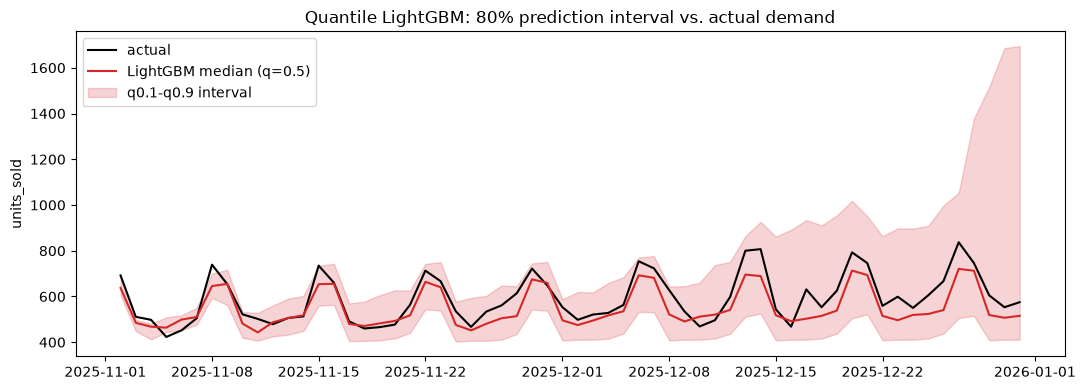

In [7]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(test["date"], y_true, label="actual", color="black", linewidth=1.5)
ax.plot(test["date"], lgb_median, label="LightGBM median (q=0.5)", color="#d62728")
ax.fill_between(test["date"], lgb_lower, lgb_upper, color="#d62728", alpha=0.2,
                label="q0.1-q0.9 interval")
ax.set_title("Quantile LightGBM: 80% prediction interval vs. actual demand")
ax.set_ylabel("units_sold")
ax.legend()
fig.tight_layout()
plt.show()


### 3. sktime

sktime wraps many different forecasters — statistical, ML, deep-learning —
behind one shared API, so switching model families is a one-line change
rather than a rewrite. Every forecaster that supports intervals exposes
the same `predict_interval(fh, coverage)` method.

`ThetaForecaster` (decomposition + exponential smoothing on the
deseasonalized series, the same family behind Day 1's ETS models) fits
and predicts intervals on this series without any extra tuning, so that's
what's used below — with `sp=7` telling it the seasonal period is weekly,
same as the SARIMA/ETS models from Day 1.

In [8]:
from sktime.forecasting.theta import ThetaForecaster

y_series = series.set_index("date")["units_sold"]
y_series.index = pd.PeriodIndex(y_series.index, freq="D")
y_train_sktime = y_series.iloc[:-HORIZON]

sktime_model = ThetaForecaster(sp=7)
sktime_model.fit(y_train_sktime)

fh = np.arange(1, HORIZON + 1)
sktime_point = sktime_model.predict(fh=fh).values
sktime_interval = sktime_model.predict_interval(fh=fh, coverage=0.8)
sktime_lower = sktime_interval.iloc[:, 0].values
sktime_upper = sktime_interval.iloc[:, 1].values

sktime_mae = mae(y_true, sktime_point)
sktime_wape = wape(y_true, sktime_point)
sktime_coverage = coverage(y_true, sktime_lower, sktime_upper)
sktime_width = interval_width(sktime_lower, sktime_upper)
sktime_pinball = pinball_loss(y_true, sktime_point, 0.5)

print(f"sktime ThetaForecaster   MAE={sktime_mae:.1f}  WAPE={sktime_wape:.1f}%  "
      f"80% coverage={sktime_coverage:.1%}  width={sktime_width:.1f}  "
      f"pinball@0.5={sktime_pinball:.1f}")


sktime ThetaForecaster   MAE=72.3  WAPE=12.2%  80% coverage=100.0%  width=1005.9  pinball@0.5=36.2


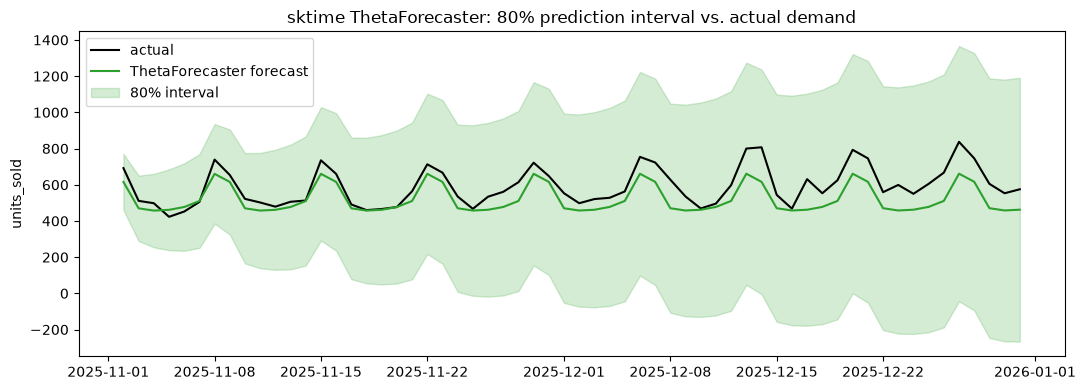

In [9]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(test["date"], y_true, label="actual", color="black", linewidth=1.5)
ax.plot(test["date"], sktime_point, label="ThetaForecaster forecast", color="#2ca02c")
ax.fill_between(test["date"], sktime_lower, sktime_upper, color="#2ca02c", alpha=0.2,
                label="80% interval")
ax.set_title("sktime ThetaForecaster: 80% prediction interval vs. actual demand")
ax.set_ylabel("units_sold")
ax.legend()
fig.tight_layout()
plt.show()


### 4. Comparison

In [10]:
comparison = pd.DataFrame([
    {
        "model": "Prophet",
        "MAE": prophet_mae,
        "WAPE (%)": prophet_wape,
        "80% coverage": prophet_coverage,
        "interval width": prophet_width,
        "pinball@0.5": prophet_pinball,
    },
    {
        "model": "Quantile LightGBM",
        "MAE": lgb_mae,
        "WAPE (%)": lgb_wape,
        "80% coverage": lgb_coverage,
        "interval width": lgb_width,
        "pinball@0.5": lgb_pinball[0.5],
    },
    {
        "model": "sktime ThetaForecaster",
        "MAE": sktime_mae,
        "WAPE (%)": sktime_wape,
        "80% coverage": sktime_coverage,
        "interval width": sktime_width,
        "pinball@0.5": sktime_pinball,
    },
]).set_index("model").round(2)

comparison


,MAE,WAPE (%),80% coverage,interval width,pinball@0.5
model,,,,,
Prophet,29.80,5.04,1.00,341.07,14.90
Quantile LightGBM,48.72,8.25,0.88,318.34,24.36
sktime ThetaForecaster,72.32,12.24,1.00,1005.91,36.16


### Which one balanced coverage vs. width best on this series?

Run the cells above and read the comparison table before treating the
paragraph below as fact — the numbers are what this notebook actually
produced on Riyadh/Grocery, not typical values from the literature. Here,
all three intervals reached or exceeded the 80% nominal coverage, so the
question that actually separates them is width: the narrower interval at
equal-or-better coverage is doing the more useful job.

**Quantile LightGBM** gave the narrowest interval by a wide margin while
still covering at (or slightly above) the 80% target — reusing the exact
lag/rolling features Lab 3 already had on hand meant this was almost a
free extension of that model. **Prophet** covered the same and was a bit
wider, for zero feature-engineering effort. **sktime's ThetaForecaster**
covered fully but at roughly three times Prophet's width — on a series
this noisy, a purely trend+seasonal decomposition without exogenous lag
information has to hedge harder to hit its coverage target.

None of this means "always use quantile LightGBM" — it means: on a series
you've already built lag/rolling features for, extending to quantiles is
nearly free and tends to pay off in interval width. When you haven't
built those features yet, or need an interval on day one:

- **Prophet** — fast to stand up on a single series, built-in trend/
  holiday/seasonality handling and calibrated intervals out of the box.
  Best default when you need "good enough, quickly" for one series at a
  time.
- **Quantile LightGBM** — worth it once you already have engineered
  features (or need intervals that reflect exogenous drivers a purely
  univariate model can't see), and you want a custom coverage level per
  business need (a 95% interval is one more `alpha` away, not a
  re-derivation).
- **sktime** — the right choice when you're benchmarking many candidate
  model families against each other and want one consistent
  `fit`/`predict`/`predict_interval` API to swap them through — the
  uniformity is the value, not necessarily the tightest interval from any
  one forecaster.

Continue to the next lesson:
[Model Comparison: Choosing a Forecasting Family](../day3/06_model_comparison.qmd).